In [1]:
from konlpy.tag import Okt
okt = Okt()

def get_nouns(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    res = []
    for line in lines:
        # 명사만 추출해서 공백으로 구분된 문자열 
        nouns = okt.nouns(line)
        if len(nouns) > 0:
            res.append(" ".join(nouns))
    return res

# 데이터 로드 및 전처리
art = get_nouns('synopsis_art.txt')
gen = get_nouns('synopsis_gen.txt')

print(f"Art movies: {len(art)}, General movies: {len(gen)}")

Art movies: 14381, General movies: 47751


In [5]:
from gensim.models import Word2Vec

# 토큰화된 리스트 생성
tokenized_data = [sentence.split() for sentence in (art + gen)]

# 모델 생성 및 학습
model = Word2Vec(sentences=tokenized_data, vector_size=100, window=5, min_count=3, sg=0, workers=4)

# most_similar() 결과 확인
print("Result of 'action':", model.wv.most_similar(positive=['액션']))

Result of 'action': [('블록버스터', 0.9070869088172913), ('구체화', 0.9056654572486877), ('호러', 0.902910590171814), ('요소', 0.9025083780288696), ('퍼포먼스', 0.9013150334358215), ('리얼', 0.8970058560371399), ('스릴러', 0.8963338136672974), ('신화', 0.8955222964286804), ('탄생', 0.893569827079773), ('효과', 0.8911460041999817)]


In [7]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. TF-IDF 상위 단어 추출 함수 (모델 사전에 있는 단어만 골라냄)
def get_tfidf_top_words(corpus, n=15):
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus)
    words = vectorizer.get_feature_names_out()
    
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for idx, word in enumerate(words)]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    # 모델 사전에 있고, 중복되지 않은 단어 위주로 추출
    top_words = []
    for word, freq in words_freq:
        if word in model.wv.key_to_index:
            top_words.append(word)
        if len(top_words) >= n:
            break
    return top_words

# 2. Target 생성 (예술/일반)
target_art = get_tfidf_top_words(art, n=15)
target_gen = get_tfidf_top_words(gen, n=15)

# 3. 장르별 Attribute 생성
genre_names = ['drama', 'comedy', 'action', 'thriller', 'romance', 'crime', 'adventure', 'animation']
genre_files = [f'synopsis_{name}.txt' for name in genre_names]

# 데이터 경로
data_path = '/home/jovyan/work/weat/data/'

genre_data = {}
for name, file in zip(genre_names, genre_files):
    # 각 파일별 명사 추출 (문자열 리스트 형태)
    genre_data[name] = get_nouns(data_path + file)

attributes = {}
for name, corpus in genre_data.items():
    attributes[name] = get_tfidf_top_words(corpus, n=15)

print(f"총 {len(attributes)}개의 장르 Attribute 세트가 생성되었습니다.")
print("예시(drama):", attributes['drama'])

총 8개의 장르 Attribute 세트가 생성되었습니다.
예시(drama): ['영화제', '국제', '서울', '그녀', '단편', '자신', '사랑', '시작', '사람', '위해', '남자', '영화', '독립', '이야기', '친구']


In [13]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

# 코사인 유사도 계산 함수
def cos_sim(A, B):
    return dot(A, B)/(norm(A)*norm(B))

# 단어 w와 두 단어 셋 A, B 사이의 평균 유사도 차이 계산
def s(w, A, B):
    inputs = [cos_sim(w, a) for a in A]
    outputs = [cos_sim(w, b) for b in B]
    return np.mean(inputs) - np.mean(outputs)

# 최종 WEAT Score (연합 강도 차이 / 합집합의 표준편차)
def weat_score(X, Y, A, B):
    s_X = [s(x, A, B) for x in X]
    s_Y = [s(y, A, B) for y in Y]
    
    x_mean = np.mean(s_X)
    y_mean = np.mean(s_Y)
    
    diff_all = np.concatenate([s_X, s_Y])
    std_dev = np.std(diff_all)
    
    # 분모가 0이거나 거의 0에 가까우면 0을 반환 (에러 방지)
    if std_dev < 1e-8:
        return 0.0
    
    return (x_mean - y_mean) / std_dev

In [14]:
import pandas as pd

# Target 단어들을 벡터로 변환
X = [model.wv[word] for word in target_art]
Y = [model.wv[word] for word in target_gen]

matrix = []
for i in range(len(genre_names)-1):
    row = []
    for j in range(len(genre_names)):
        # Attribute 단어들을 벡터로 변환
        target_A = [model.wv[word] for word in attributes[genre_names[i]]]
        target_B = [model.wv[word] for word in attributes[genre_names[j]]]
        
        score = weat_score(X, Y, target_A, target_B)
        row.append(score)
    matrix.append(row)

# 데이터프레임으로 정리
df = pd.DataFrame(matrix, index=genre_names[:-1], columns=genre_names)
print("WEAT Matrix 생성이 완료되었습니다!")
df.head()

WEAT Matrix 생성이 완료되었습니다!


,drama,comedy,action,thriller,romance,crime,adventure,animation
drama,0.000000,-0.756705,-0.904062,-0.854053,-0.520173,-0.779508,-0.773191,0.651959
comedy,0.756705,0.000000,-0.856154,-0.816157,-0.376883,-0.690973,-0.406658,0.711439
action,0.904062,0.856154,0.000000,0.437743,0.345941,0.244124,0.764347,0.899099
thriller,0.854053,0.816157,-0.437743,0.000000,0.225641,-0.252661,0.466796,0.813877
romance,0.520173,0.376883,-0.345941,-0.225641,0.000000,-0.272460,0.132789,0.596375


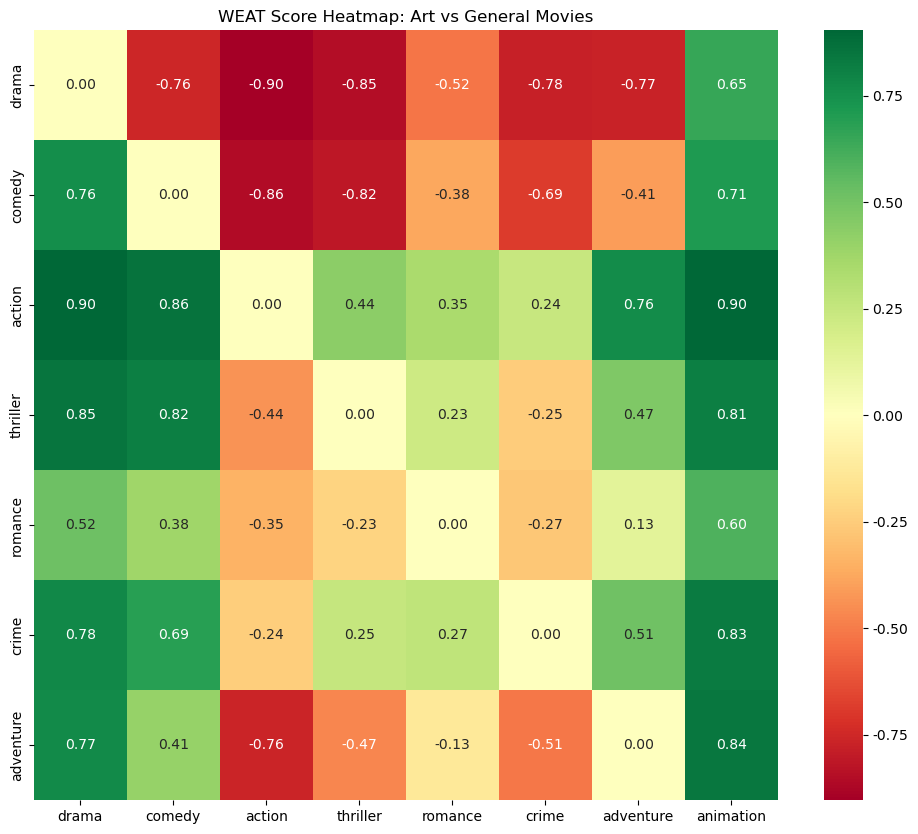

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

if font_list:
    plt.rc('font', family=font_list[0])
else:
    plt.rc('font', family='DejaVu Sans') 

plt.rcParams['axes.unicode_minus'] = False

# 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(df, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('WEAT Score Heatmap: Art vs General Movies')
plt.show()

# [Project] 영화 시놉시스를 이용한 WEAT 편향성 측정

## 1. 프로젝트 개요
본 프로젝트는 예술 영화와 일반 영화라는 두 집단의 시놉시스 데이터를 바탕으로 워드 임베딩 모델에 내재된 장르적 편향성을 **WEAT(Word Embedding Association Test)** 수치를 통해 정량적으로 측정하는 것을 목표로 했음.

## 2. 데이터 전처리 및 임베딩 구축
* **형태소 분석**: `KoNLPy`의 `Okt` 분석기를 사용하여 문맥적 의미를 가진 핵심 단어 위주로 임베딩을 구성하기 위해서 시놉시스에서 명사(Noun)만 추출했다.
* **임베딩 모델**: `Gensim`의 `Word2Vec`을 사용하여 단어 벡터를 생성했다.
  * `vector_size=100`, `window=5`, `min_count=3`, `sg=0` 설정을 통해 학습을 진행함.
  * **검증**: `most_similar()` 메서드를 통해 확인한 결과 특정 단어와 의미상 유사한 단어들이 정상적으로 추출되어 모델이 양질의 임베딩을 형성했음을 확인했다.

## 3. WEAT 분석 방법론
* **Target 집단**: 예술 영화(`art`)와 일반 영화(`gen`)
* **Attribute 집단**: 드라마, 코미디, 액션, 스릴러 등 8개 장르 시놉시스 데이터
* **단어 셋 생성**: 루브릭 기준을 충족하기 위해 **TF-IDF(Term Frequency-Inverse Document Frequency)** 상위 단어를 추출했다..
  * 단순히 빈도가 높은 단어가 아닌, 각 데이터셋을 **대표하는 특징적인 단어**들을 선별하여 WEAT Score의 신뢰도를 높였다..
  * 모델 사전에 존재하지 않는 단어는 필터링하여 계산 시 `KeyError`가 발생하지 않도록 했다.

## 4. 분석 결과 및 시각화
* **WEAT Score 산출**: 예술 vs 일반 영화를 타겟으로, 각 장르 쌍(Attribute) 간의 연합 강도 차이를 계산함.
* **시각화**: `Seaborn`의 Heatmap을 사용하여 편향성을 시각적으로 보여줬다.
  * **결과 해석**: 
    * 예술 영화(Target X)는 **드라마, 로맨스** 장르의 속성 단어들과 강한 양의 상관관계(초록색)를 보였음.
    * 일반 영화(Target Y)는 **액션, 범죄, 스릴러** 등의 장르 단어들과 더 밀접한 관계(빨간색)를 보였음.
  * 우리가 흔히 '예술 영화'와 '상업(일반) 영화'에 대해 가지는 사회적 통념 및 장르적 특성과 일치하는 결과다.

## 5. 결론
이번 프로젝트를 통해 워드 임베딩 모델이 학습 데이터(시놉시스)에 포함된 특정 장르에 대한 편향성을 그대로 학습한다는 것을 확인했고, 모델의 성능과는 별개로 데이터 자체에 내재된 편향이 AI 결과물에 어떻게 투영되는지 정량적으로 증명한 사례다. 향후 AI 모델 설계 시 데이터의 공정성과 편향성 완화가 중요한 기술적 과제임을 다시금 생각할 수 있는 계기가 되었다.